In [2]:
from pathlib import Path
from datetime import datetime, timedelta
import time

import requests
import numpy as np
import pandas as pd
import xarray as xr
import rioxarray as rxr
import matplotlib.pyplot as plt
import cartopy 
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import glob

In [23]:
lat_min, lat_max = 30.0, 35.0
lon_min, lon_max = -89.0, -81.6
year = 2016
scale = "4WK"
download_dir = Path('data/raw/esi/2016_4WK/')

In [25]:

def open_and_clip_tif(path, lon_min, lat_min, lon_max, lat_max):
    da = rxr.open_rasterio(path, masked=True).squeeze()

    # Most GeoTIFFs should already have CRS, but set it if missing
    if da.rio.crs is None:
        da = da.rio.write_crs("EPSG:4326")

    da = da.rio.clip_box(
        minx=lon_min,
        miny=lat_min,
        maxx=lon_max,
        maxy=lat_max
    )

    da = da.rename({"x": "lon", "y": "lat"})

    # Remove leftover scalar band coord if present
    if "band" in da.coords:
        da = da.reset_coords("band", drop=True)

    return da


In [ ]:
from datetime import datetime
import pandas as pd
import xarray as xr

# read all downloaded tif files
tif_files = sorted(download_dir.glob("*.tif"))

da_list = []

for path in tif_files:
    try:
        da = open_and_clip_tif(path, lon_min, lat_min, lon_max, lat_max)

        year_doy = path.stem.split("_")[-1]
        file_time = datetime.strptime(year_doy, "%Y%j")

        da = da.expand_dims(time=[pd.Timestamp(file_time)])
        da_list.append(da)

    except Exception as e:
        print(f"Skipping {path.name}: {e}")

if not da_list:
    raise ValueError("No readable files found.")

esi_4wk = xr.concat(da_list, dim="time").sortby("time")
esi_4wk.name = "esi_4wk"

# save one file
out_file = download_dir / f"esi_{year}_{scale}.nc"
esi_4wk.to_netcdf(out_file)

print(f"Saved: {out_file}")

Skipping DFPPM_4WK_2016225.tif: DFPPM_4WK_2016225.tif: TIFFReadDirectory:Failed to read directory at offset 22453598
Saved: data/raw/esi/2016_4WK/esi_2016_4WK.nc


In [3]:
esi_4wk = xr.open_dataset('data/raw/esi/2016_4WK/esi_2016_4WK.nc')
esi_4wk.load()

<xarray.Dataset> Size: 6MB
Dimensions:      (time: 51, lat: 100, lon: 148)
Coordinates:
  * time         (time) datetime64[ns] 408B 2016-01-08 2016-01-15 ... 2016-12-30
  * lon          (lon) float64 1kB -88.97 -88.92 -88.87 ... -81.72 -81.67 -81.62
  * lat          (lat) float64 800B 34.97 34.92 34.87 ... 30.12 30.07 30.02
Data variables:
    spatial_ref  int64 8B 0
    esi_4wk      (time, lat, lon) float64 6MB 0.1629 0.2344 ... 1.443 -9.999e+03

In [4]:
x = (esi_4wk.where(esi_4wk > -9000)).count()

y =(esi_4wk == -9.999e+03).sum()

In [5]:
(y/x)*100

<xarray.Dataset> Size: 16B
Dimensions:      ()
Data variables:
    spatial_ref  float64 8B 0.0
    esi_4wk      float64 8B 5.511

In [6]:
esi_4wk = esi_4wk.where(esi_4wk > -9000)

In [10]:
print("Time range:")
print(esi_4wk.time.min().values, "to", esi_4wk.time.max().values)

print("\nLat range:")
print(float(esi_4wk.lat.min().values), "to", float(esi_4wk.lat.max().values))

print("\nLon range:")
print(float(esi_4wk.lon.min().values), "to", float(esi_4wk.lon.max().values))

Time range:
2016-01-08T00:00:00.000000000 to 2016-12-30T00:00:00.000000000

Lat range:
30.02499999999999 to 34.974999999999994

Lon range:
-88.975 to -81.62499999999999


In [23]:
esi_4wk

<xarray.Dataset> Size: 6MB
Dimensions:      (time: 51, lat: 100, lon: 148)
Coordinates:
  * time         (time) datetime64[ns] 408B 2016-01-08 2016-01-15 ... 2016-12-30
  * lon          (lon) float64 1kB -88.97 -88.92 -88.87 ... -81.72 -81.67 -81.62
  * lat          (lat) float64 800B 34.97 34.92 34.87 ... 30.12 30.07 30.02
Data variables:
    spatial_ref  float64 8B 0.0
    esi_4wk      (time, lat, lon) float64 6MB 0.1629 0.2344 ... 1.443 nan

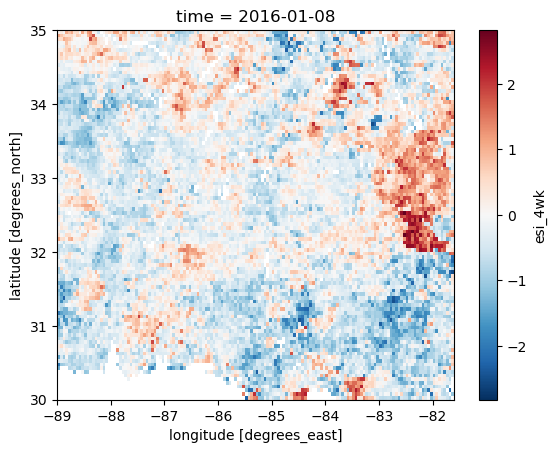

In [24]:
esi_4wk["esi_4wk"].isel(time=0).plot()

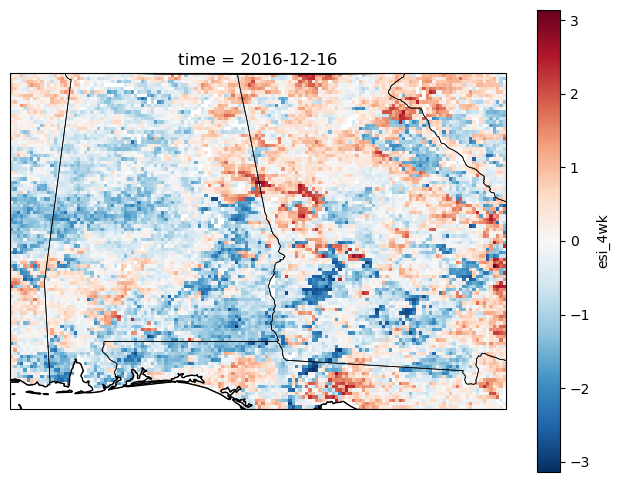

In [28]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig, ax = plt.subplots(
    figsize=(8, 6),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

esi_4wk["esi_4wk"].isel(time=48).plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='RdBu_r'
)

ax.add_feature(cfeature.STATES, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.8)
ax.add_feature(cfeature.COASTLINE)

ax.set_extent([-89, -81.6, 30, 35])  # optional (your SE U.S. box)

plt.show()


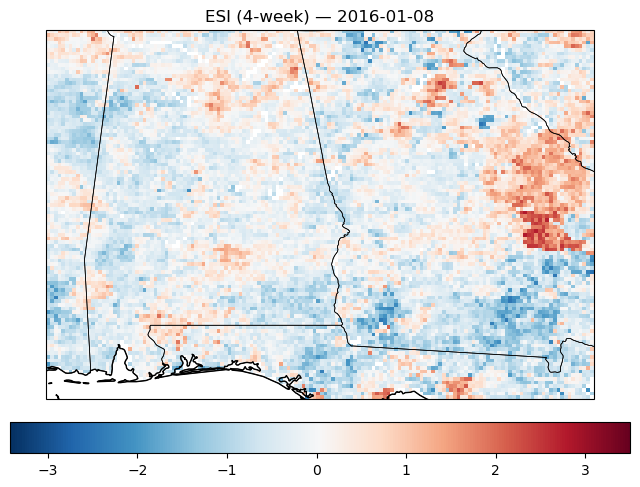

In [32]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import cartopy.crs as ccrs
import cartopy.feature as cfeature

esi = esi_4wk["esi_4wk"]

# consistent color scale (important for interpretation)
vmin = float(esi.min())
vmax = float(esi.max())

fig, ax = plt.subplots(
    figsize=(8, 6),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

def update(frame):
    ax.clear()

    # plot data
    esi.isel(time=frame).plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap='RdBu_r',
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False
    )

    # map features
    ax.add_feature(cfeature.STATES, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.8)
    ax.add_feature(cfeature.COASTLINE)

    ax.set_extent([-89, -81.6, 30, 35])

    # title with date
    date = str(esi.time.isel(time=frame).values)[:10]
    ax.set_title(f"ESI (4-week) — {date}")
# before animation
im = esi.isel(time=0).plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='RdBu_r',
    vmin=vmin,
    vmax=vmax,
    add_colorbar=False
)
cbar = plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.05)
# create animation
ani = animation.FuncAnimation(
    fig,
    update,
    frames=esi.sizes["time"],
    interval=300
)

# save as GIF
ani.save("esi_2016_4wk_cartopy.gif", writer="pillow", fps=4)

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import cartopy.crs as ccrs
import cartopy.feature as cfeature

esi = esi_4wk["esi_4wk"]

# regional mean time series
esi_mean = esi.mean(dim=("lat", "lon"))

# consistent color scale
vmin = float(esi.min())
vmax = float(esi.max())

# figure layout
fig = plt.figure(figsize=(8, 8))
gs = fig.add_gridspec(2, 1, height_ratios=[3, 1])

# --- map axis ---
ax_map = fig.add_subplot(gs[0], projection=ccrs.PlateCarree())

# --- time series axis ---
ax_ts = fig.add_subplot(gs[1])

# plot full time series once (static)
ax_ts.plot(esi_mean.time, esi_mean, color='black')
dot, = ax_ts.plot([], [], 'ro')  # moving point

ax_ts.set_title("Regional Mean ESI (4-week)")
ax_ts.set_xlabel("Time")
ax_ts.set_ylabel("ESI")

def update(frame):
    ax_map.clear()

    # map
    esi.isel(time=frame).plot(
        ax=ax_map,
        transform=ccrs.PlateCarree(),
        cmap='RdBu_r',
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False
    )

    ax_map.add_feature(cfeature.STATES, linewidth=0.5)
    ax_map.add_feature(cfeature.BORDERS, linewidth=0.8)
    ax_map.add_feature(cfeature.COASTLINE)
    ax_map.set_extent([-89, -81.6, 30, 35])

    date = esi.time.isel(time=frame).values
    ax_map.set_title(f"ESI (4-week) — {str(date)[:10]}")

    # moving dot
    dot.set_data(
        [esi_mean.time.isel(time=frame).values],
        [esi_mean.isel(time=frame).values]
    )

    return dot,

ani = animation.FuncAnimation(
    fig,
    update,
    frames=esi.sizes["time"],
    interval=50
)

ani.save("esi_map_timeseries_year.gif", writer="pillow", fps=4)

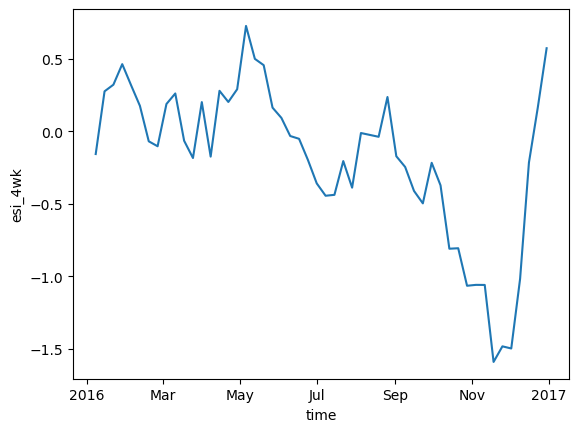

In [39]:
esi_regional_mean = esi_4wk["esi_4wk"].mean(dim=("lat", "lon"))
esi_regional_mean.plot()

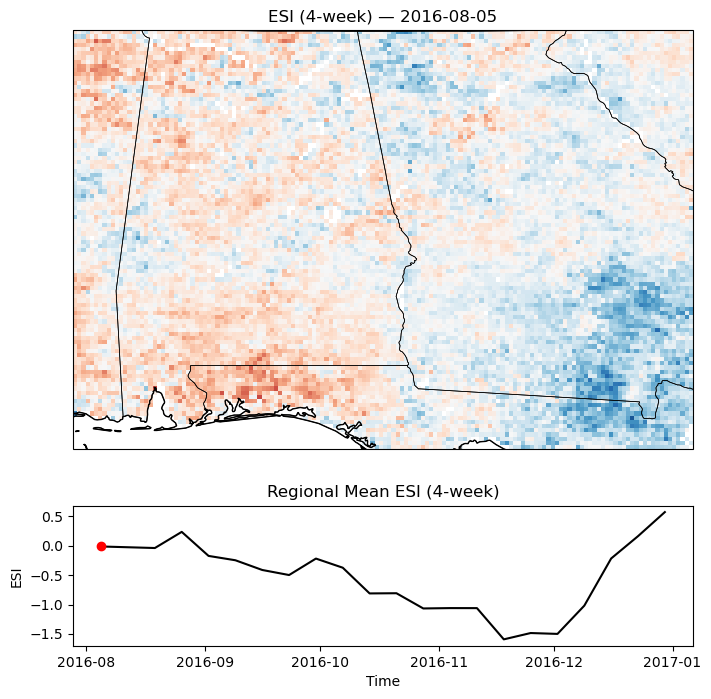

In [42]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import cartopy.crs as ccrs
import cartopy.feature as cfeature

esi = esi_4wk["esi_4wk"]
esi = esi.sel(time=slice("2016-08-01", "2016-12-31"))

# regional mean time series
esi_mean = esi.mean(dim=("lat", "lon"))

# consistent color scale
vmin = float(esi.min())
vmax = float(esi.max())

# figure layout
fig = plt.figure(figsize=(8, 8))
gs = fig.add_gridspec(2, 1, height_ratios=[3, 1])

# --- map axis ---
ax_map = fig.add_subplot(gs[0], projection=ccrs.PlateCarree())

# --- time series axis ---
ax_ts = fig.add_subplot(gs[1])

# plot full time series once (static)
ax_ts.plot(esi_mean.time, esi_mean, color='black')
dot, = ax_ts.plot([], [], 'ro')  # moving point

ax_ts.set_title("Regional Mean ESI (4-week)")
ax_ts.set_xlabel("Time")
ax_ts.set_ylabel("ESI")

def update(frame):
    ax_map.clear()

    # map
    esi.isel(time=frame).plot(
        ax=ax_map,
        transform=ccrs.PlateCarree(),
        cmap='RdBu_r',
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False
    )

    ax_map.add_feature(cfeature.STATES, linewidth=0.5)
    ax_map.add_feature(cfeature.BORDERS, linewidth=0.8)
    ax_map.add_feature(cfeature.COASTLINE)
    ax_map.set_extent([-89, -81.6, 30, 35])

    date = esi.time.isel(time=frame).values
    ax_map.set_title(f"ESI (4-week) — {str(date)[:10]}")

    # moving dot
    dot.set_data(
        [esi_mean.time.isel(time=frame).values],
        [esi_mean.isel(time=frame).values]
    )

    return dot,

ani = animation.FuncAnimation(
    fig,
    update,
    frames=esi.sizes["time"],
    interval=50
)

ani.save("esi_map_timeseries_both.gif", writer="pillow", fps=4)